# Sentiment Analysis — Transformer Fine-Tuning

Fine-tunes a pretrained DistilBERT to classify tweet sentiment into **positive / neutral / negative**.

**Dataset:** [abhi8923shriv/sentiment-analysis-dataset](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset) — provides `train.csv` and `test.csv` with columns `textID, text, selected_text, sentiment, ...`.

**Runtime:** CPU will work but is slow. A Colab T4 GPU trains 3 epochs in a few minutes. GPU is used automatically if available.


## 1. Setup

In [1]:
# Colab: uncomment to install. Local: install once in your venv.
# !pip install -q transformers datasets accelerate scikit-learn

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


## 2. Load & inspect dataset

Point `DATA_ROOT` at the folder where you extracted the Kaggle zip. Expected files: `train.csv`, `test.csv`.


In [3]:
DATA_ROOT = 'archive'  # local: folder with train.csv/test.csv. For Colab, re-point (e.g. '/content/archive').

train_df = pd.read_csv(os.path.join(DATA_ROOT, 'train.csv'), encoding='latin-1')
test_df  = pd.read_csv(os.path.join(DATA_ROOT, 'test.csv'),  encoding='latin-1')

print('train shape:', train_df.shape)
print('test  shape:', test_df.shape)
train_df.head()

train shape: (27481, 10)
test  shape: (4815, 9)


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [4]:
# Keep only the columns we need, drop nulls
for name, df in [('train', train_df), ('test', test_df)]:
    print(f'--- {name} ---')
    print('nulls:\n', df[['text', 'sentiment']].isna().sum())
    print('sentiment counts:\n', df['sentiment'].value_counts(dropna=False))
    print()

train_df = train_df[['text', 'sentiment']].dropna().reset_index(drop=True)
test_df  = test_df[['text',  'sentiment']].dropna().reset_index(drop=True)

print('after dropna — train:', train_df.shape, 'test:', test_df.shape)
assert set(train_df['sentiment'].unique()) == {'positive', 'neutral', 'negative'}
assert set(test_df['sentiment'].unique())  == {'positive', 'neutral', 'negative'}

--- train ---
nulls:
 text         1
sentiment    0
dtype: int64
sentiment counts:
 sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

--- test ---
nulls:
 text         1281
sentiment    1281
dtype: int64
sentiment counts:
 sentiment
neutral     1430
NaN         1281
positive    1103
negative    1001
Name: count, dtype: int64

after dropna — train: (27480, 2) test: (3534, 2)


In [5]:
# Text length sanity check — confirms max_length=128 is safe
lens = train_df['text'].str.split().apply(len)
print('word-count percentiles:')
print(lens.quantile([0.5, 0.9, 0.99, 1.0]))

word-count percentiles:
0.50    12.0
0.90    23.0
0.99    28.0
1.00    33.0
Name: text, dtype: float64


## 3. Preprocess

Label mapping: `negative=0, neutral=1, positive=2`. Stratified 90/10 split off `train.csv`; `test.csv` is held out untouched.


In [6]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}

train_df['label'] = train_df['sentiment'].map(label2id)
test_df['label']  = test_df['sentiment'].map(label2id)

train_split, val_split = train_test_split(
    train_df, test_size=0.1, stratify=train_df['label'], random_state=SEED
)
print('train:', len(train_split), 'val:', len(val_split), 'test:', len(test_df))

train_ds = Dataset.from_pandas(train_split[['text', 'label']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_split[['text', 'label']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))

train: 24732 val: 2748 test: 3534


## 4. Tokenize

In [7]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True, remove_columns=['text'])
val_tok   = val_ds.map(tokenize,   batched=True, remove_columns=['text'])
test_tok  = test_ds.map(tokenize,  batched=True, remove_columns=['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  # dynamic padding per batch

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24732 [00:00<?, ? examples/s]

Map:   0%|          | 0/2748 [00:00<?, ? examples/s]

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]

## 5. Model

`DistilBertForSequenceClassification` with a fresh 3-way classification head. Full fine-tuning (no frozen layers).


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Train

Standard BERT-family fine-tuning recipe: AdamW, LR 2e-5, linear warmup, 3 epochs, weight decay 0.01. Best checkpoint (by macro-F1 on val) is reloaded at the end.


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

In [10]:
training_args = TrainingArguments(
    output_dir='./ckpt-sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
    save_total_limit=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,   # transformers 5.x: renamed from `tokenizer=`
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


/Users/sampriti/Downloads/cmi/AML_5/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.530306,0.538225,0.785298,0.789179
2,0.441939,0.517439,0.795124,0.798641
3,0.356472,0.553258,0.794396,0.797853


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/sampriti/Downloads/cmi/AML_5/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/sampriti/Downloads/cmi/AML_5/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2319, training_loss=0.4926045312095994, metrics={'train_runtime': 247.3479, 'train_samples_per_second': 299.966, 'train_steps_per_second': 9.375, 'total_flos': 815182687141416.0, 'train_loss': 0.4926045312095994, 'epoch': 3.0})

## 7. Evaluate on the held-out test set

In [11]:
pred_out = trainer.predict(test_tok)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=-1)

target_names = ['negative', 'neutral', 'positive']
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

/Users/sampriti/Downloads/cmi/AML_5/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative     0.7998    0.7742    0.7868      1001
     neutral     0.7451    0.7909    0.7673      1430
    positive     0.8586    0.8150    0.8363      1103

    accuracy                         0.7937      3534
   macro avg     0.8012    0.7934    0.7968      3534
weighted avg     0.7960    0.7937    0.7944      3534



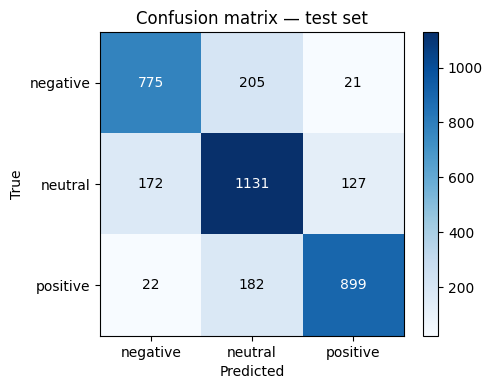

In [12]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3), target_names)
ax.set_yticks(range(3), target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax); plt.title('Confusion matrix — test set'); plt.tight_layout(); plt.show()

## 8. Sanity check on hand-written sentences

Confirms the label mapping survived end-to-end — if these look wrong, the `label2id` / `id2label` wiring is off.


In [13]:
samples = [
    "absolutely loved the new update, works beautifully",
    "the meeting is scheduled for tomorrow at noon",
    "this is the worst experience i've ever had, completely broken",
]

model.eval()
enc = tokenizer(samples, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(model.device)
with torch.no_grad():
    logits = model(**enc).logits
preds = logits.argmax(dim=-1).cpu().tolist()

for s, p in zip(samples, preds):
    print(f'[{id2label[p]:>8}]  {s}')

[positive]  absolutely loved the new update, works beautifully
[ neutral]  the meeting is scheduled for tomorrow at noon
[negative]  this is the worst experience i've ever had, completely broken
